# FeatureGraph evaluation: synthetic ground truth, baseline comparison, and sensitivity

This notebook evaluates FeatureGraph 0.1.0a1 as a behavioral-object
constructor. Unlike the demonstration notebook, it begins with signals
whose true troughs, peaks, boundaries, durations, amplitudes, and
symmetries are known.

The evaluation asks four questions:

1. Does FeatureGraph recover clean oscillation objects and their properties?
2. How does recovery change as observation noise increases?
3. How sensitive is recovery to smoothing, `diff_lag`, and `eps`?
4. How does object recovery compare with a SciPy peak/trough baseline?

All reported comparisons use deterministic seeds and one-to-one matching
between detected and true oscillations. FeatureGraph and the baseline are
evaluated against the same ground-truth objects.


In [1]:
import json
import platform
from dataclasses import dataclass
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

import featuregraph as fg

SEED = 1729
rng = np.random.default_rng(SEED)
OUTPUT_DIR = Path("paper_artifacts/evaluation")
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

print(f"FeatureGraph {fg.__version__}; seed={SEED}")


FeatureGraph 0.1.0a1; seed=1729


## 1. Evaluation protocol

A true oscillation is a complete trough–peak–trough interval. Detected
objects are matched to true objects by peak location, subject to a maximum
localization tolerance. Each detected and true object can be used at most
once.

Object recovery is summarized by precision, recall, and F1. For matched
objects, the notebook also reports mean absolute error (MAE) for start,
peak, end, duration, amplitude, and temporal symmetry.

The SciPy baseline detects positive and negative peaks and constructs an
object only when two consecutive detected troughs contain a detected peak.
This gives the baseline the same trough–peak–trough output schema required
for object-level comparison.


In [2]:
@dataclass(frozen=True)
class SyntheticConfig:
    cycles: int = 12
    period: int = 80
    amplitude: float = 1.0
    baseline: float = 0.0
    noise_std: float = 0.0
    seed: int = SEED


def make_synthetic_oscillations(config):
    """Return observations and exact trough–peak–trough objects."""
    # A half-cycle of right-edge context makes the final true trough
    # observable for every evaluated difference lag. This context is
    # not included as an additional ground-truth object.
    index = np.arange(
        config.cycles * config.period + config.period // 2
    )
    clean = (
        config.baseline
        - config.amplitude
        * np.cos(2 * np.pi * index / config.period)
    )
    local_rng = np.random.default_rng(config.seed)
    observed = clean + local_rng.normal(
        0.0, config.noise_std, size=len(index)
    )

    observations = pd.DataFrame(
        {
            "sequence": 0,
            "sample_index": index,
            "signal_clean": clean,
            "signal": observed,
        }
    )

    starts = np.arange(config.cycles) * config.period
    peaks = starts + config.period // 2
    ends = starts + config.period
    truth = pd.DataFrame(
        {
            "true_id": np.arange(config.cycles),
            "start_index": starts,
            "peak_index": peaks,
            "end_index": ends,
            "duration": config.period,
            "amplitude": config.amplitude,
            "temporal_symmetry": 1.0,
        }
    )
    return observations, truth


observations, truth = make_synthetic_oscillations(SyntheticConfig())
truth.head()


,true_id,start_index,peak_index,end_index,duration,amplitude,temporal_symmetry
0,0,0,40,80,80,1.0000,1.0000
1,1,80,120,160,80,1.0000,1.0000
2,2,160,200,240,80,1.0000,1.0000
3,3,240,280,320,80,1.0000,1.0000
4,4,320,360,400,80,1.0000,1.0000


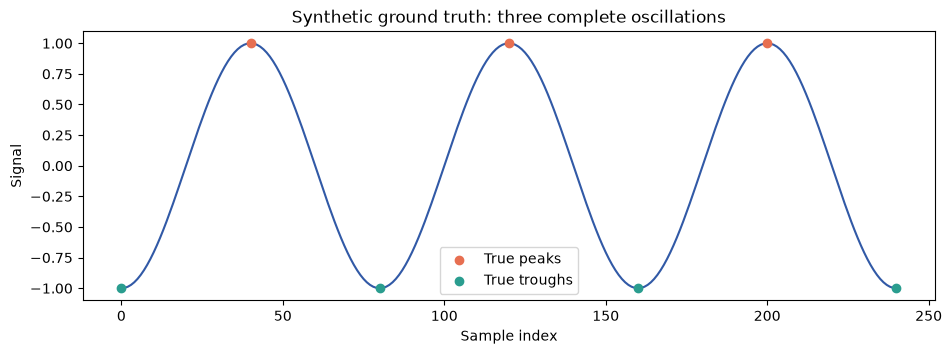

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(
    observations["sample_index"].iloc[:241],
    observations["signal"].iloc[:241],
    color="#3159a6",
)
ax.scatter(
    truth["peak_index"].iloc[:3],
    np.repeat(1.0, 3),
    color="#e76f51",
    label="True peaks",
    zorder=3,
)
ax.scatter(
    truth["start_index"].iloc[:4],
    np.repeat(-1.0, 4),
    color="#2a9d8f",
    label="True troughs",
    zorder=3,
)
ax.set(
    title="Synthetic ground truth: three complete oscillations",
    xlabel="Sample index",
    ylabel="Signal",
)
ax.legend()
fig.savefig(
    FIGURE_DIR / "synthetic_ground_truth.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 2. Construction and baseline adapters

These functions normalize both methods to the same object schema. The
FeatureGraph adapter returns only complete objects. The baseline uses
`find_peaks` for maxima and minima, then converts adjacent troughs with an
intervening peak into bounded oscillation objects.


In [4]:
OBJECT_COLUMNS = [
    "start_index",
    "peak_index",
    "end_index",
    "duration",
    "amplitude",
    "temporal_symmetry",
]


def construct_featuregraph(
    observations,
    *,
    smooth_window=1,
    diff_lag=1,
    eps=0.0,
):
    constructor = fg.oscillation.Oscillation(
        signals="signal",
        group="sequence",
        smooth_signal=smooth_window > 1,
        smooth_window=smooth_window,
        diff_lag=diff_lag,
        eps=eps,
    )
    features = constructor.fit_transform(observations)
    objects = constructor.summarize(features, "signal")
    return objects.table.loc[:, OBJECT_COLUMNS].copy(), features


def construct_scipy_baseline(
    observations,
    *,
    expected_period,
    prominence=0.25,
):
    values = observations["signal"].to_numpy()
    distance = max(1, int(expected_period * 0.45))
    peak_indices, _ = find_peaks(
        values,
        distance=distance,
        prominence=prominence,
    )
    trough_indices, _ = find_peaks(
        -values,
        distance=distance,
        prominence=prominence,
    )
    if values[0] < values[1]:
        trough_indices = np.insert(trough_indices, 0, 0)

    rows = []
    for start, end in zip(trough_indices[:-1], trough_indices[1:]):
        candidates = peak_indices[
            (peak_indices > start) & (peak_indices < end)
        ]
        if len(candidates) == 0:
            continue
        peak = candidates[np.argmax(values[candidates])]
        rise = peak - start
        fall = end - peak
        duration = end - start
        rows.append(
            {
                "start_index": start,
                "peak_index": peak,
                "end_index": end,
                "duration": duration,
                "amplitude": (
                    values[peak]
                    - (values[start] + values[end]) / 2
                ) / 2,
                "temporal_symmetry": (
                    1 - abs(rise - fall) / duration
                ),
            }
        )
    return pd.DataFrame(rows, columns=OBJECT_COLUMNS)


## 3. One-to-one object matching and metrics

Matching is deliberately separated from construction. Candidate pairs are
ordered by absolute peak-location error, and the smallest nonconflicting
pairs are accepted within the tolerance. Unmatched detections are false
positives; unmatched true objects are false negatives.


In [5]:
def match_objects(detected, truth, tolerance):
    candidates = []
    for detected_index, detected_row in detected.iterrows():
        for true_index, true_row in truth.iterrows():
            peak_error = abs(
                detected_row["peak_index"] - true_row["peak_index"]
            )
            if peak_error <= tolerance:
                candidates.append(
                    (peak_error, detected_index, true_index)
                )

    used_detected = set()
    used_truth = set()
    matches = []
    for _, detected_index, true_index in sorted(candidates):
        if (
            detected_index in used_detected
            or true_index in used_truth
        ):
            continue
        used_detected.add(detected_index)
        used_truth.add(true_index)
        matches.append((detected_index, true_index))

    return matches


def score_objects(detected, truth, tolerance):
    matches = match_objects(detected, truth, tolerance)
    true_positives = len(matches)
    false_positives = len(detected) - true_positives
    false_negatives = len(truth) - true_positives

    precision = (
        true_positives / (true_positives + false_positives)
        if true_positives + false_positives
        else 0.0
    )
    recall = (
        true_positives / (true_positives + false_negatives)
        if true_positives + false_negatives
        else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall
        else 0.0
    )

    result = {
        "detected": len(detected),
        "truth": len(truth),
        "matched": true_positives,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    error_columns = [
        "start_index",
        "peak_index",
        "end_index",
        "duration",
        "amplitude",
        "temporal_symmetry",
    ]
    for column in error_columns:
        errors = [
            abs(
                detected.loc[detected_index, column]
                - truth.loc[true_index, column]
            )
            for detected_index, true_index in matches
        ]
        result[f"{column}_mae"] = (
            float(np.mean(errors)) if errors else np.nan
        )
    return result


## 4. Clean-signal recovery

The clean-signal experiment is an implementation check. With `diff_lag=1`,
no smoothing, and zero tolerance, the generated extrema align exactly with
sample locations. A correct trough–peak–trough construction should recover
all complete objects without inventing extras.


In [6]:
clean_detected, clean_features = construct_featuregraph(
    observations,
    smooth_window=1,
    diff_lag=1,
    eps=0.0,
)
clean_score = pd.Series(
    score_objects(
        clean_detected,
        truth,
        tolerance=SyntheticConfig().period // 4,
    ),
    name="FeatureGraph",
)
clean_score


detected                12.0000
truth                   12.0000
matched                 12.0000
precision                1.0000
recall                   1.0000
f1                       1.0000
start_index_mae          0.0000
peak_index_mae           0.0000
end_index_mae            0.0000
duration_mae             0.0000
amplitude_mae            0.0000
temporal_symmetry_mae    0.0000
Name: FeatureGraph, dtype: float64

In [7]:
clean_comparison = truth.merge(
    clean_detected,
    left_index=True,
    right_index=True,
    suffixes=("_true", "_detected"),
)
clean_comparison.head(8)


,true_id,start_index_true,peak_index_true,end_index_true,duration_true,amplitude_true,temporal_symmetry_true,start_index_detected,peak_index_detected,end_index_detected,duration_detected,amplitude_detected,temporal_symmetry_detected
0,0,0,40,80,80,1.0000,1.0000,0.0000,40.0000,80.0000,80.0000,1.0000,1.0000
1,1,80,120,160,80,1.0000,1.0000,80.0000,120.0000,160.0000,80.0000,1.0000,1.0000
2,2,160,200,240,80,1.0000,1.0000,160.0000,200.0000,240.0000,80.0000,1.0000,1.0000
3,3,240,280,320,80,1.0000,1.0000,240.0000,280.0000,320.0000,80.0000,1.0000,1.0000
4,4,320,360,400,80,1.0000,1.0000,320.0000,360.0000,400.0000,80.0000,1.0000,1.0000
5,5,400,440,480,80,1.0000,1.0000,400.0000,440.0000,480.0000,80.0000,1.0000,1.0000
6,6,480,520,560,80,1.0000,1.0000,480.0000,520.0000,560.0000,80.0000,1.0000,1.0000
7,7,560,600,640,80,1.0000,1.0000,560.0000,600.0000,640.0000,80.0000,1.0000,1.0000


## 5. Noise robustness and baseline comparison

For each noise level, ten independently seeded signals are generated.
FeatureGraph uses one fixed configuration throughout the experiment:
a 9-sample moving average, `diff_lag=5`, and `eps=0`. The SciPy baseline
also uses one fixed configuration. Parameters are not retuned for each
noise level.

This experiment evaluates one declared operating point; it does not claim
that either configuration is globally optimal.


In [8]:
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20, 0.30, 0.40]
REPLICATES = 10
PERIOD = 80
TOLERANCE = PERIOD // 4

robustness_rows = []
for noise_std, replicate in product(
    NOISE_LEVELS, range(REPLICATES)
):
    config = SyntheticConfig(
        period=PERIOD,
        noise_std=noise_std,
        seed=SEED + replicate,
    )
    noisy_observations, noisy_truth = (
        make_synthetic_oscillations(config)
    )

    featuregraph_detected, _ = construct_featuregraph(
        noisy_observations,
        smooth_window=9,
        diff_lag=5,
        eps=0.0,
    )
    baseline_detected = construct_scipy_baseline(
        noisy_observations,
        expected_period=PERIOD,
        prominence=0.25,
    )

    for method, detected in [
        ("FeatureGraph", featuregraph_detected),
        ("SciPy baseline", baseline_detected),
    ]:
        robustness_rows.append(
            {
                "noise_std": noise_std,
                "replicate": replicate,
                "method": method,
                **score_objects(
                    detected,
                    noisy_truth,
                    tolerance=TOLERANCE,
                ),
            }
        )

robustness = pd.DataFrame(robustness_rows)
robustness_summary = (
    robustness.groupby(["method", "noise_std"], sort=False)
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        peak_mae=("peak_index_mae", "mean"),
        start_mae=("start_index_mae", "mean"),
        end_mae=("end_index_mae", "mean"),
        duration_mae=("duration_mae", "mean"),
        amplitude_mae=("amplitude_mae", "mean"),
    )
    .reset_index()
)
robustness_summary


,method,noise_std,f1_mean,f1_std,precision_mean,recall_mean,peak_mae,start_mae,end_mae,duration_mae,amplitude_mae
0,FeatureGraph,0.0000,1.0000,0.0000,1.0000,1.0000,6.0000,6.5000,6.0000,0.5000,0.0204
1,SciPy baseline,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,FeatureGraph,0.0500,1.0000,0.0000,1.0000,1.0000,5.9167,6.5250,6.0500,1.2250,0.0178
3,SciPy baseline,0.0500,0.9826,0.0225,1.0000,0.9667,1.6735,1.5409,1.6045,2.1758,0.0580
4,FeatureGraph,0.1000,0.9729,0.0365,0.9495,1.0000,5.8250,6.5500,7.5333,3.7833,0.0203
5,SciPy baseline,0.1000,0.9586,0.0381,0.9609,0.9583,2.2417,5.7500,6.3447,11.0492,0.1729
6,FeatureGraph,0.2000,0.8341,0.0794,0.7229,1.0000,5.3667,6.9667,11.7250,11.2750,0.0381
7,SciPy baseline,0.2000,0.8195,0.0558,0.6978,1.0000,3.3000,14.2583,15.3250,27.7000,0.2172
8,FeatureGraph,0.3000,0.6818,0.0777,0.5221,1.0000,4.7333,8.3417,16.0667,19.6417,0.0746
9,SciPy baseline,0.3000,0.8073,0.0421,0.6788,1.0000,4.3000,14.2917,18.4667,29.9750,0.1741


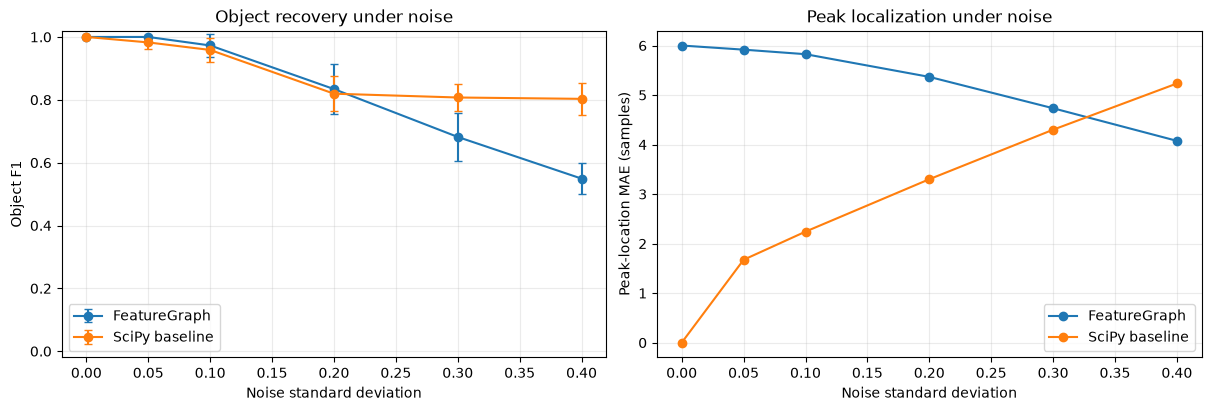

In [9]:
fig, axes = plt.subplots(
    1, 2, figsize=(12, 4), constrained_layout=True
)
for method, method_table in robustness_summary.groupby(
    "method", sort=False
):
    axes[0].errorbar(
        method_table["noise_std"],
        method_table["f1_mean"],
        yerr=method_table["f1_std"].fillna(0),
        marker="o",
        capsize=3,
        label=method,
    )
    axes[1].plot(
        method_table["noise_std"],
        method_table["peak_mae"],
        marker="o",
        label=method,
    )

axes[0].set(
    title="Object recovery under noise",
    xlabel="Noise standard deviation",
    ylabel="Object F1",
    ylim=(-0.02, 1.02),
)
axes[1].set(
    title="Peak localization under noise",
    xlabel="Noise standard deviation",
    ylabel="Peak-location MAE (samples)",
)
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
fig.savefig(
    FIGURE_DIR / "noise_robustness.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 6. Parameter sensitivity

Sensitivity is evaluated at a fixed noise standard deviation of 0.20.
The schema, object definition, matching rule, and ground truth remain
unchanged. Only smoothing window, difference lag, and tolerance vary.

A smoothing window of 1 means that the raw signal is used.


In [10]:
SMOOTH_WINDOWS = [1, 5, 9, 15]
DIFF_LAGS = [1, 3, 5, 10]
EPS_VALUES = [0.0, 0.01, 0.03]
SENSITIVITY_REPLICATES = 5

sensitivity_rows = []
for smooth_window, diff_lag, eps, replicate in product(
    SMOOTH_WINDOWS,
    DIFF_LAGS,
    EPS_VALUES,
    range(SENSITIVITY_REPLICATES),
):
    config = SyntheticConfig(
        period=PERIOD,
        noise_std=0.20,
        seed=SEED + replicate,
    )
    noisy_observations, noisy_truth = (
        make_synthetic_oscillations(config)
    )
    detected, _ = construct_featuregraph(
        noisy_observations,
        smooth_window=smooth_window,
        diff_lag=diff_lag,
        eps=eps,
    )
    sensitivity_rows.append(
        {
            "smooth_window": smooth_window,
            "diff_lag": diff_lag,
            "eps": eps,
            "replicate": replicate,
            **score_objects(
                detected,
                noisy_truth,
                tolerance=TOLERANCE,
            ),
        }
    )

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_summary = (
    sensitivity.groupby(
        ["smooth_window", "diff_lag", "eps"],
        sort=False,
    )
    .agg(
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        peak_mae=("peak_index_mae", "mean"),
        duration_mae=("duration_mae", "mean"),
    )
    .reset_index()
    .sort_values(
        ["f1_mean", "peak_mae"],
        ascending=[False, True],
    )
)
sensitivity_summary.head(15)


,smooth_window,diff_lag,eps,f1_mean,f1_std,precision_mean,recall_mean,peak_mae,duration_mae
47,15,10,0.0300,1.0000,0.0000,1.0000,1.0000,10.9167,1.9667
46,15,10,0.0100,1.0000,0.0000,1.0000,1.0000,11.2833,1.8667
45,15,10,0.0000,1.0000,0.0000,1.0000,1.0000,11.4167,1.8000
34,9,10,0.0100,0.9840,0.0219,0.9692,1.0000,8.3333,2.8833
42,15,5,0.0000,0.9840,0.0219,0.9692,1.0000,9.1167,2.7167
33,9,10,0.0000,0.9766,0.0346,0.9560,1.0000,8.4833,2.1667
35,9,10,0.0300,0.9624,0.0529,0.9314,1.0000,7.9333,4.1000
44,15,5,0.0300,0.9538,0.0421,0.9143,1.0000,7.8833,5.6500
43,15,5,0.0100,0.9458,0.0342,0.8989,1.0000,8.7333,4.6333
21,5,10,0.0000,0.8502,0.0701,0.7443,1.0000,6.3000,7.8000


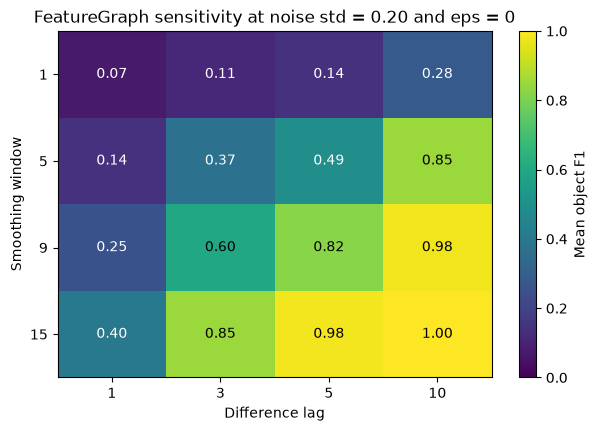

In [11]:
heatmap_table = (
    sensitivity.loc[sensitivity["eps"].eq(0.0)]
    .groupby(["smooth_window", "diff_lag"])["f1"]
    .mean()
    .unstack("diff_lag")
)

fig, ax = plt.subplots(figsize=(7, 4.5))
image = ax.imshow(
    heatmap_table.to_numpy(),
    vmin=0,
    vmax=1,
    cmap="viridis",
    aspect="auto",
)
ax.set_xticks(
    range(len(heatmap_table.columns)),
    labels=heatmap_table.columns,
)
ax.set_yticks(
    range(len(heatmap_table.index)),
    labels=heatmap_table.index,
)
ax.set(
    title="FeatureGraph sensitivity at noise std = 0.20 and eps = 0",
    xlabel="Difference lag",
    ylabel="Smoothing window",
)
for row in range(heatmap_table.shape[0]):
    for column in range(heatmap_table.shape[1]):
        value = heatmap_table.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < 0.55 else "black",
        )
fig.colorbar(image, ax=ax, label="Mean object F1")
fig.savefig(
    FIGURE_DIR / "parameter_sensitivity.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 7. Boundary completeness and group isolation

The final diagnostic checks two structural invariants:

- boundary-truncated intervals are excluded from the default object table;
- construction state does not cross independent group boundaries.

Two sequences are concatenated into one DataFrame. Each begins at a
different phase, so an implementation that leaks `diff` or cumulative
identity across the boundary can create a spurious object.


In [12]:
group_frames = []
expected_by_group = {}
for group_id, phase_shift in [(0, 0), (1, 17)]:
    config = SyntheticConfig(cycles=6, period=PERIOD, seed=SEED)
    group_observations, _ = make_synthetic_oscillations(config)
    shifted_index = (
        group_observations["sample_index"] + phase_shift
    )
    group_observations["signal"] = -np.cos(
        2 * np.pi * shifted_index / PERIOD
    )
    group_observations["sequence"] = group_id
    group_frames.append(group_observations)

grouped_observations = pd.concat(
    group_frames, ignore_index=True
)
grouped_constructor = fg.oscillation.Oscillation(
    signals="signal",
    group="sequence",
    smooth_signal=False,
    diff_lag=1,
    eps=0.0,
)
grouped_features = grouped_constructor.fit_transform(
    grouped_observations
)
grouped_objects = grouped_constructor.summarize(
    grouped_features,
    "signal",
    include_partial=True,
)

structural_diagnostic = (
    grouped_objects.table.groupby("sequence")
    .agg(
        all_objects=("oscillation_id", "size"),
        complete_objects=("is_complete", "sum"),
        partial_objects=(
            "is_complete",
            lambda values: (~values).sum(),
        ),
    )
    .reset_index()
)
structural_diagnostic


,sequence,all_objects,complete_objects,partial_objects
0,0,8,6,2
1,1,8,6,2


In [13]:
complete_grouped_objects = grouped_constructor.summarize(
    grouped_features,
    "signal",
    include_partial=False,
)

assert clean_score["precision"] == 1.0
assert clean_score["recall"] == 1.0
assert clean_score["f1"] == 1.0
assert clean_score["start_index_mae"] <= 1.0
assert clean_score["peak_index_mae"] <= 1.0
assert clean_score["end_index_mae"] <= 1.0
assert complete_grouped_objects.table["is_complete"].all()
assert set(complete_grouped_objects.table["sequence"]) == {0, 1}

print("All clean-recovery and structural assertions passed.")


All clean-recovery and structural assertions passed.


## 8. Paper-ready outputs

The following cell writes the principal numeric artifacts used by the
evaluation:

- clean-signal recovery metrics;
- robustness metrics for every replicate;
- aggregated robustness results;
- parameter-sensitivity results;
- the structural boundary diagnostic.

These files are derived outputs. They should be regenerated from the
tagged code and recorded environment rather than edited manually.


In [14]:
clean_score.to_frame("value").to_csv(
    OUTPUT_DIR / "clean_recovery.csv"
)
robustness.to_csv(
    OUTPUT_DIR / "noise_robustness_replicates.csv",
    index=False,
)
robustness_summary.to_csv(
    OUTPUT_DIR / "noise_robustness_summary.csv",
    index=False,
)
sensitivity.to_csv(
    OUTPUT_DIR / "parameter_sensitivity_replicates.csv",
    index=False,
)
sensitivity_summary.to_csv(
    OUTPUT_DIR / "parameter_sensitivity_summary.csv",
    index=False,
)
structural_diagnostic.to_csv(
    OUTPUT_DIR / "structural_diagnostic.csv",
    index=False,
)

manifest = {
    "featuregraph_version": fg.__version__,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "seed": SEED,
    "cycles": SyntheticConfig().cycles,
    "period": PERIOD,
    "noise_levels": NOISE_LEVELS,
    "robustness_replicates": REPLICATES,
    "matching_tolerance_samples": TOLERANCE,
    "featuregraph_operating_point": {
        "smooth_window": 9,
        "diff_lag": 5,
        "eps": 0.0,
    },
    "scipy_operating_point": {
        "minimum_peak_distance_fraction_of_period": 0.45,
        "prominence": 0.25,
    },
    "sensitivity_grid": {
        "smooth_windows": SMOOTH_WINDOWS,
        "diff_lags": DIFF_LAGS,
        "eps_values": EPS_VALUES,
        "replicates": SENSITIVITY_REPLICATES,
    },
}
(OUTPUT_DIR / "evaluation_manifest.json").write_text(
    json.dumps(manifest, indent=2) + "\n",
    encoding="utf-8",
)

print(f"Wrote evaluation artifacts to {OUTPUT_DIR.resolve()}")


Wrote evaluation artifacts to /workspaces/featuregraph/notebooks/paper_artifacts/evaluation


## Interpretation and limitations

This notebook evaluates deterministic recovery of a declared synthetic
oscillation definition. It supports claims about boundary construction,
object properties, parameter sensitivity, and degradation under additive
Gaussian noise.

It does **not** establish that every real waveform has a unique correct
trough–peak–trough interpretation. It also does not evaluate irregular
timestamps, missing observations, nested frequencies, or expert agreement
on real physiological and industrial data. Those require separate
experiments and should remain explicit limitations in the first paper.

The SciPy comparison is a detector baseline, not a comparison with another
behavioral-object framework. Its purpose is to separate extrema detection
performance from FeatureGraph's additional representational output:
identities, completeness, properties, construction evidence, composition,
and queries.
